# Investigations on the Students' Mental Health Dataset

## Data Preprocessing

In [62]:
#install packages
%pip install pyod
from pyod.models.iforest import IForest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
from itertools import product

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
#import dataset
df = pd.read_csv("/Users/caiqingming/Desktop/stat3011_part1/students.csv")

In [64]:
df.describe()

,age,stay,todep,tosc,toas
count,268.000000,268.000000,268.000000,268.000000,268.000000
mean,20.873134,2.149254,8.186567,37.473881,72.380597
std,2.765279,1.326805,4.954728,9.234120,22.644888
min,17.000000,1.000000,0.000000,8.000000,36.000000
25%,19.000000,1.000000,5.000000,31.000000,56.000000
50%,20.000000,2.000000,8.000000,40.000000,72.000000
75%,22.000000,3.000000,11.000000,46.000000,88.000000
max,31.000000,10.000000,25.000000,48.000000,145.000000


In [65]:
# Identifying null values
df.isna().sum()

inter_dom        0
gender           0
academic         0
age              0
stay             0
japanese_cate    0
english_cate     0
religion         0
todep            0
tosc             0
toas             0
dtype: int64

In [66]:
# Removing extreme values from the data
limit_dict = {}

for col_name in df.columns:
    if (df[col_name].dtype in ['int64', 'float64']):
        q1 = df[col_name].quantile(0.25)
        q3 = df[col_name].quantile(0.75)
        iqr = q3 - q1
        upper_limit = q3 + (3.5*iqr)
        lower_limit = q1 - (3.5*iqr)
        limit_dict[col_name] = [lower_limit, upper_limit]

cond = pd.Series([True]*len(df), index=df.index)
for key, limits in limit_dict.items():
    lower = limits[0]
    upper = limits[1]
    cond = cond & (df[key] >= lower) & (df[key] <= upper)

print(f'Original number of samples: {len(df)}')
clean_df = df[cond]
print(f'Number of samples after cleaning: {len(clean_df)}')

Original number of samples: 268
Number of samples after cleaning: 268


The results show that our dataset does not have extreme values.

In [67]:
# Encoding categorical columns
processed_df= pd.get_dummies(df, dtype=int)
from sklearn.preprocessing import QuantileTransformer
numeric_cols = ["age", "stay", "todep", "tosc", "toas"]

# Standardizing numeric columns
qt = QuantileTransformer(n_quantiles = 268, output_distribution="normal")
processed_df[numeric_cols] = qt.fit_transform(processed_df[numeric_cols])

## Anomaly Detection

We first define functions for hyperparameter tuning.

In [68]:
def evaluate_outlier_classifier(model, data):
    model.fit(data.values)
    labels = model.predict(data.values)
    # Return inliers
    return data[labels == 0]

In [69]:
def evaluate_regressor(inliers):
    X = inliers.drop(['todep'], axis=1)
    y = inliers['todep']
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    preds = lr.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)

    return round(rmse, 3)

### Hyperparameter tuning of three models (IForest, KNN, LOF)

Hyperparameter tuning of IForest

In [70]:
# Optimizing contaminations
contaminations = [0.05, 0.1, 0.2, 0.3]
scores = dict()
for c in contaminations:
  iforest = IForest(contamination=c, random_state=10)
  inliers = evaluate_outlier_classifier(iforest, processed_df)
  scores[c] = evaluate_regressor(inliers)
print(scores) # scores represent rmse

{0.05: 1.053, 0.1: 1.036, 0.2: 1.165, 0.3: 0.891}


In [71]:
# Optimizing estimators and max_samples
estimators = [100, 200, 300]
max_samples = [0.6, 0.8, 1]
scores = dict()
for e in estimators:
    for m in max_samples:
        iforest = IForest(n_estimators=e, max_samples=m, contamination=0.3, random_state=10)
        inliers = evaluate_outlier_classifier(iforest, processed_df)
        scores[(e, m)] = evaluate_regressor(inliers)
#print RMSEs
print(scores)

{(100, 0.6): 1.159, (100, 0.8): 1.181, (100, 1): 1.266, (200, 0.6): 1.147, (200, 0.8): 0.852, (200, 1): 1.266, (300, 0.6): 0.946, (300, 0.8): 1.007, (300, 1): 1.266}


In [72]:
# Building IForest model to identify outliers
iforest = IForest(n_estimators=200, max_samples=0.8, contamination=.3, n_jobs=-1, random_state=10)
iforest.fit(processed_df.values)
probs = iforest.predict_proba(processed_df.values)
iforest_outlier_probs = probs[:, 1]
iforest_outliers = processed_df[iforest_outlier_probs >= 0.75]
#print the numbers of outliers
print(len(iforest_outliers))

13


Hyperparameter tuning of KNN

In [73]:
def evaluate_outlier_classifier2(model, data, threshold=.75):
    model.fit(data)
    probs = model.predict_proba(data)
    inliers = data[probs[:, 1] <= threshold]
    return inliers

In [74]:
def evaluate_regressor2(inliers):
    X, y = inliers.drop("todep", axis=1), inliers[['todep']]
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    preds = lr.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    return round(rmse, 3)

In [75]:
# Optimizing n_neighbors
n_neighbors = [5, 10, 15, 20]
scores = dict()
for k in n_neighbors:
    knn = KNN(n_neighbors=k,n_jobs=-1)
    knn.fit(processed_df.values)
    inliers = evaluate_outlier_classifier2(knn, processed_df, .75)
    scores[k] = evaluate_regressor2(inliers)
print(scores) #print RMSEs

{5: 1.463, 10: 1.159, 15: 1.508, 20: 1.271}


In [76]:
# Optimizing distance metric and methods
ps = [1, 2, 3, 4]
methods = ["largest", "mean", "median"]
scores = dict()
for p, method in product(ps, methods):
    # Init an instance of KNN
    knn = KNN(n_neighbors=10, method=method, contamination=0.1, p=p, n_jobs=-1)
    # Find the inliers with the current KNN
    inliers = evaluate_outlier_classifier2(knn, processed_df, .75)
    # Calculate and store RMSE into scores
    scores[(p, method)] = evaluate_regressor(inliers)
print(scores) #print RMSEs

{(1, 'largest'): 1.266, (1, 'mean'): 1.266, (1, 'median'): 1.266, (2, 'largest'): 1.159, (2, 'mean'): 1.482, (2, 'median'): 1.463, (3, 'largest'): 0.977, (3, 'mean'): 1.277, (3, 'median'): 1.228, (4, 'largest'): 0.746, (4, 'mean'): 1.21, (4, 'median'): 0.724}


In [77]:
# Building KNN model to identify outliers
knn = KNN(contamination=0.1,n_neighbors=10, method='median', p=4, n_jobs=-1)
knn.fit(processed_df.values)
probs = knn.predict_proba(processed_df.values)
is_outlier = probs[:, 1] > 0.75
outliers = processed_df[is_outlier]
len(outliers) #print the numbers of outliers

22

Hyperparameter tuning of LOF

In [78]:
# Optimizing n_neighbors and distance metrics
n_neighbors = [5, 10, 15, 20]
metrics = ['euclidean', 'manhattan']
scores = dict()

for k in n_neighbors:
    for m in metrics:
        lof = LOF(n_neighbors=k, metric=m, n_jobs=-1)
        inliers = evaluate_outlier_classifier2(lof, processed_df, .75)
        scores[(k, m)] = evaluate_regressor2(inliers)
print(scores) #print RMSEs

{(5, 'euclidean'): 1.424, (5, 'manhattan'): 1.412, (10, 'euclidean'): 1.292, (10, 'manhattan'): 1.424, (15, 'euclidean'): 1.167, (15, 'manhattan'): 1.424, (20, 'euclidean'): 1.029, (20, 'manhattan'): 1.115}


In [79]:
# Building LOF model to identify outliers
lof = LOF(n_neighbors=20, contamination=0.1,metric="euclidean",n_jobs=-1)
lof.fit(processed_df)
probs = lof.predict_proba(processed_df)
is_outlier = probs[:, 1] > 0.75
outliers = processed_df[is_outlier]
len(outliers) #print the numbers of outliers

6

### Evaluation of detectors (IForest, KNN, LOF) using a doping process

This part differs slightly from the report. We encoded the categorical columns on a copy of the original dataset to avoid double encoding.

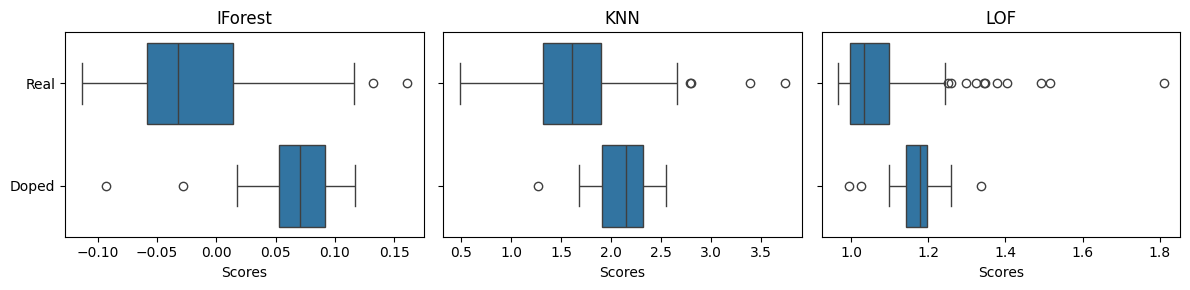

In [80]:
np.random.seed(0)
df = pd.read_csv('/Users/caiqingming/Desktop/stat3011_part1/students.csv').copy()
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)

cat_features = [x for x in df.columns if df[x].nunique() <= 10]
num_features = [x for x in df.columns if x not in cat_features]


min_cols_per_modification = 1
max_cols_per_modification = 5

doped_df = df.copy().head(20)

for i in doped_df.index:
    num_cols_modified = -1
    while (num_cols_modified < min_cols_per_modification) or (num_cols_modified > max_cols_per_modification):
        num_cols_modified = int(abs(np.random.laplace(1.0, 10)))

    modified_cols = np.random.choice(df.columns, num_cols_modified, replace=False)

    for col_name in modified_cols:
        other_cols = df.columns.tolist()
        other_cols.remove(col_name)

        if col_name in num_features:
            regr = RandomForestRegressor(random_state=0, n_jobs=-1)
            regr.fit(df[other_cols], df[col_name])

            pred = regr.predict(pd.DataFrame(doped_df.loc[i, other_cols]).T)[0]
            pred_quantile = stats.percentileofscore(df[col_name], pred) // 25

            cur_val = doped_df.loc[i, col_name]
            cur_val_quantile = stats.percentileofscore(df[col_name], cur_val) // 25

            quantiles_list = list(range(4))
            np.random.shuffle(quantiles_list)
            for q in quantiles_list:
                if q != pred_quantile and q != cur_val_quantile:
                    break

            doped_df.loc[i, col_name] = (0.25 * q) + 0.125 + np.random.random() / 20


def test_detector(model, title, real_df, doped_df, ax):
    model.fit(real_df.values)

    real_scores = model.decision_function(real_df.values)
    doped_scores = model.decision_function(doped_df.values)

    test_df = pd.DataFrame({
        "Scores": np.concatenate([real_scores, doped_scores]),
        "Source": (["Real"] * len(real_scores)) + (["Doped"] * len(doped_scores))
    })

    sns.boxplot(data=test_df, orient="h", x="Scores", y="Source", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Scores")
    ax.set_ylabel("")

models = {
    "IForest": IForest(n_estimators=200, max_samples=0.8, contamination=0.3, n_jobs=-1, random_state=10),
    "KNN": KNN(contamination=0.1,n_neighbors=10, method='median', p=4, n_jobs=-1)   ,
    "LOF":  LOF(n_neighbors=20, contamination=0.1,metric="euclidean",n_jobs=-1)
}


fig, axes = plt.subplots(nrows=1, ncols=len(models), sharey=True, figsize=(12, 3))

for ax, (name, model) in zip(axes, models.items()):
    test_detector(model, name, df, doped_df, ax)

plt.tight_layout()
plt.show()

In [81]:
# Evaluating detectors(IForest,KNN,LOF) using AUROC
from sklearn.metrics import roc_auc_score

test_df = pd.concat([df, doped_df])
y_true = [0]*len(df) + [1]*len(doped_df)

clf = IForest(n_estimators=200, max_samples=0.8, contamination=0.3, n_jobs=-1, random_state=10)
clf.fit(df.values)
y_pred = clf.decision_function(test_df.values)
if_auroc = roc_auc_score(y_true, y_pred)

clf = KNN(contamination=0.1,n_neighbors=10, method='median', p=4, n_jobs=-1)
clf.fit(df.values)
y_pred = clf.decision_function(test_df.values)
knn_auroc = roc_auc_score(y_true, y_pred)

clf = LOF(n_neighbors=20, contamination=0.1,metric="euclidean",n_jobs=-1)
clf.fit(df.values)
y_pred = clf.decision_function(test_df.values)
lof_auroc = roc_auc_score(y_true, y_pred)

In [82]:
#Printing the AUROC of each detector
print(if_auroc, knn_auroc, lof_auroc)

0.861473880597015 0.8256529850746268 0.8344216417910447


Since both the boxplots and AUROC results show that IForest performs the best among these three detectors, we chose IForest as the primary outlier detection model in this project.

### Visualisation of Outliers detected by IForest

In [83]:
# Showing outliers detected by IForest in original data
original_df = pd.read_csv("/Users/caiqingming/Desktop/stat3011_part1/students.csv")
original_outliers = original_df.loc[iforest_outliers.index]

print(original_outliers)

    inter_dom  gender academic  age  stay japanese_cate english_cate religion  \
0       Inter    Male     Grad   24     5       Average         High      Yes   
1       Inter    Male     Grad   28     1          High         High       No   
2       Inter    Male     Grad   25     6          High         High      Yes   
7       Inter  Female     Grad   30     2           Low          Low      Yes   
9       Inter    Male     Grad   31     2           Low         High      Yes   
10      Inter  Female     Grad   28     1           Low          Low      Yes   
12      Inter    Male     Grad   29     1           Low         High      Yes   
14      Inter  Female     Grad   31     1           Low      Average       No   
16      Inter  Female     Grad   31     1           Low      Average       No   
25      Inter  Female     Grad   25     8          High         High       No   
155     Inter    Male    Under   21     4       Average      Average       No   
201       Dom  Female     Gr

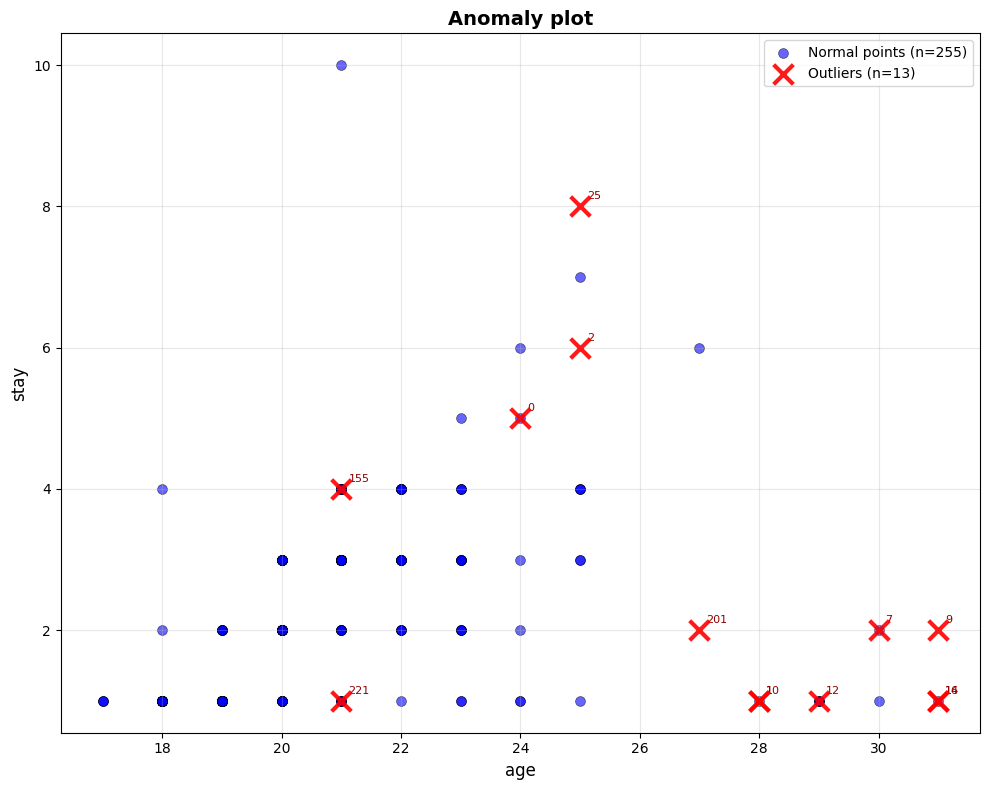

In [84]:
# Plotting Anomaly plot
import matplotlib.pyplot as plt
import numpy as np

original_df = pd.read_csv("/Users/caiqingming/Desktop/stat3011_part1/students.csv")

inliers_original = original_df.loc[processed_df[iforest_outlier_probs < 0.75].index]
outliers_original = original_df.loc[iforest_outliers.index]

plt.figure(figsize=(10, 8))

# normal points
plt.scatter(inliers_original['age'], inliers_original['stay'],
           c='blue', alpha=0.6, s=50, label=f'Normal points (n={len(inliers_original)})',
           edgecolors='black', linewidth=0.5)

# abnormal points
plt.scatter(outliers_original['age'], outliers_original['stay'],
           c='red', alpha=0.9, s=200, marker='x', linewidths=3,
           label=f'Outliers (n={len(outliers_original)})', zorder=5)

# Annotate outlier points with their index
for idx in outliers_original.index:
    plt.annotate(str(idx),
                (outliers_original.loc[idx, 'age'], outliers_original.loc[idx, 'stay']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='darkred')

plt.xlabel('age', fontsize=12)
plt.ylabel('stay', fontsize=12)
plt.title('Anomaly plot', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Explainable AI

### Investigate difference in Graduate ratio of *total samples* and *outliers*

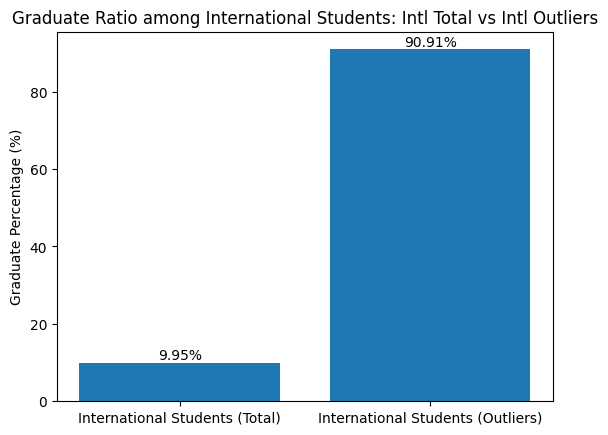

In [85]:
# The proportion of graduate students among international students
inter_total = original_df[original_df['inter_dom'] == 'Inter']
international_outliers = iforest_outliers[iforest_outliers['inter_dom_Inter'] == 1]
grad_ratio_inter = len(inter_total[inter_total['academic'] == 'Grad']) / len(inter_total) * 100

# The proportion of graduate students among international student outliers (IForest)
inter_outliers_original = original_df.loc[international_outliers.index]
grad_ratio_inter_outlier = len(inter_outliers_original[inter_outliers_original['academic'] == 'Grad']) / len(inter_outliers_original) * 100

# Plotting diagram
bars = plt.bar(['International Students (Total)', 'International Students (Outliers)'], [grad_ratio_inter, grad_ratio_inter_outlier])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}%', ha='center', va='bottom')

plt.ylabel('Graduate Percentage (%)')
plt.title('Graduate Ratio among International Students: Intl Total vs Intl Outliers')
plt.show()

Since the proportion of graduate students among international outliers is significantly larger than that in total international students, we will focus on outliers of international students at graduate level.

### Plot SHAP Waterfall plot and Decision plot for all international outliers

##### Waterfall Plot for each outlier

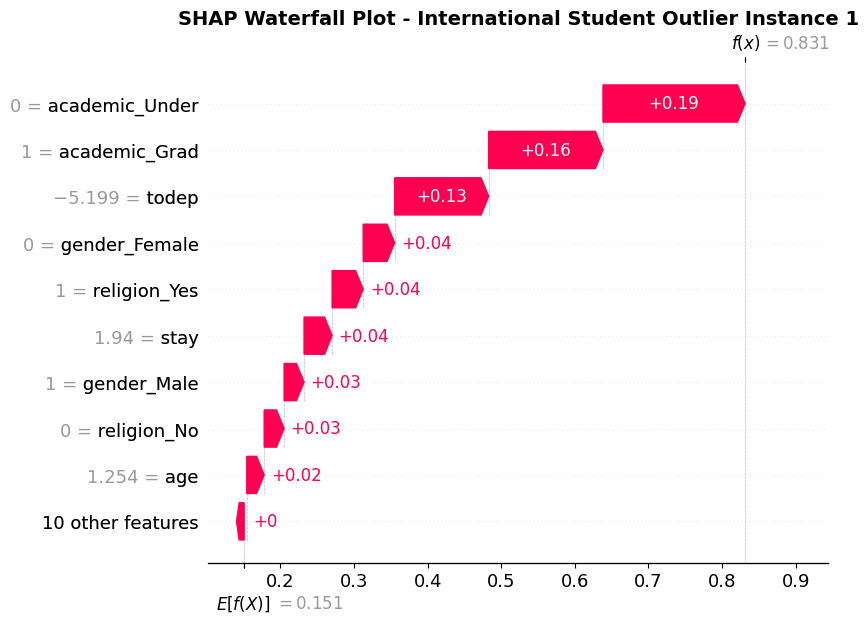

<Figure size 1000x600 with 0 Axes>

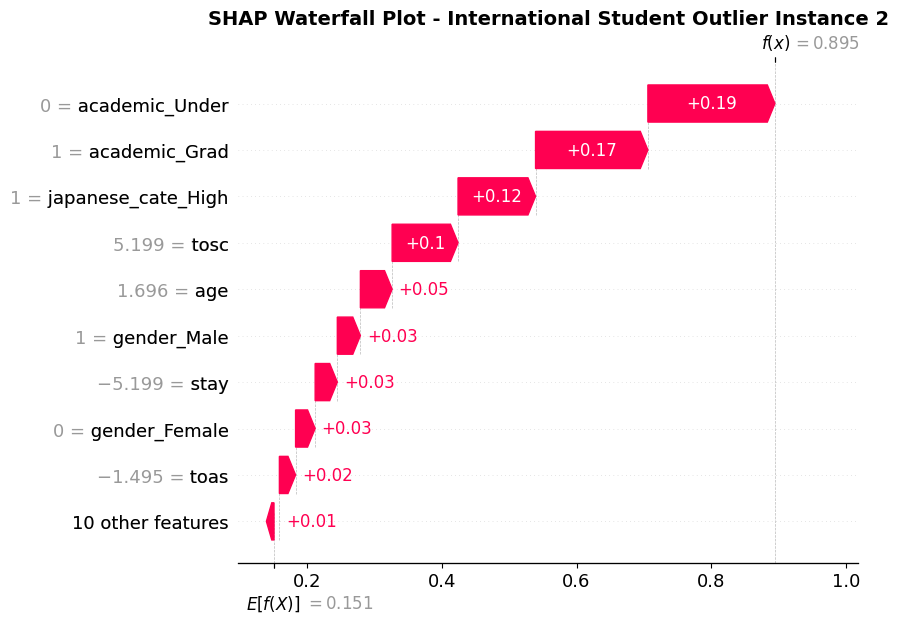

<Figure size 1000x600 with 0 Axes>

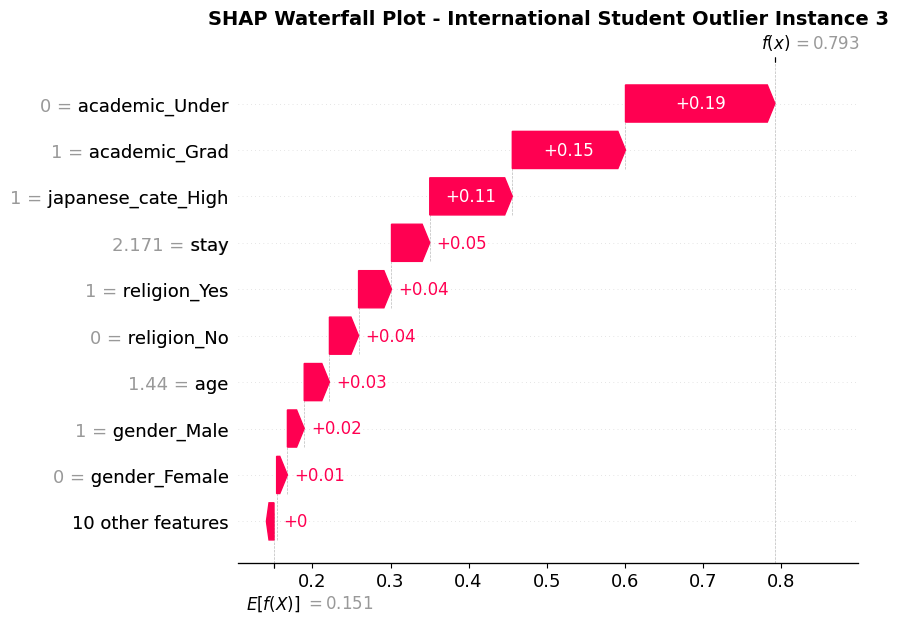

<Figure size 1000x600 with 0 Axes>

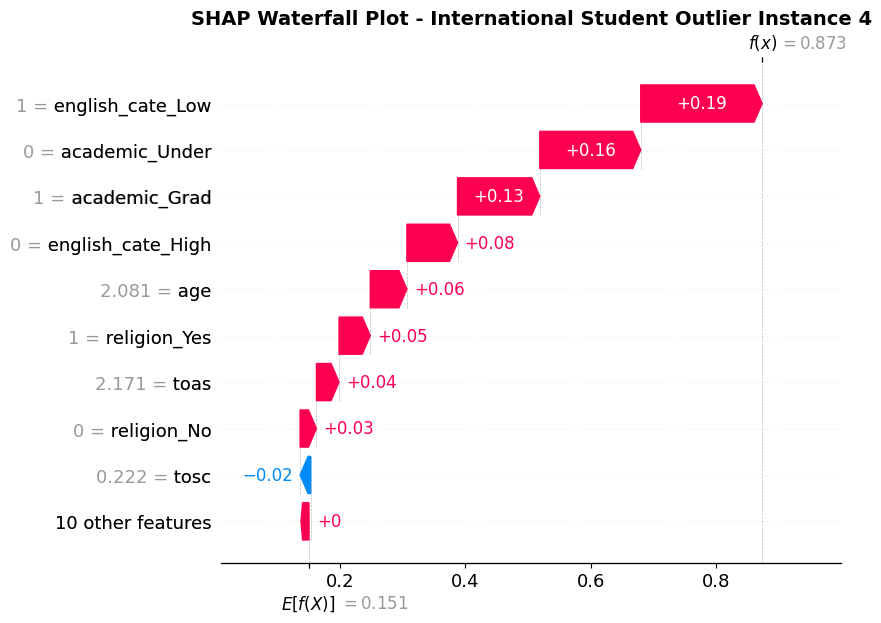

<Figure size 1000x600 with 0 Axes>

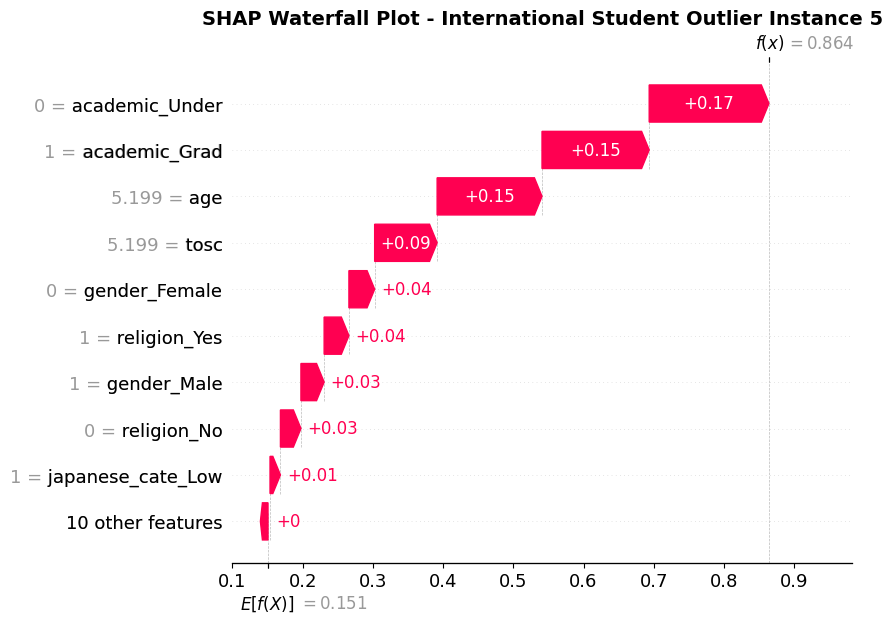

<Figure size 1000x600 with 0 Axes>

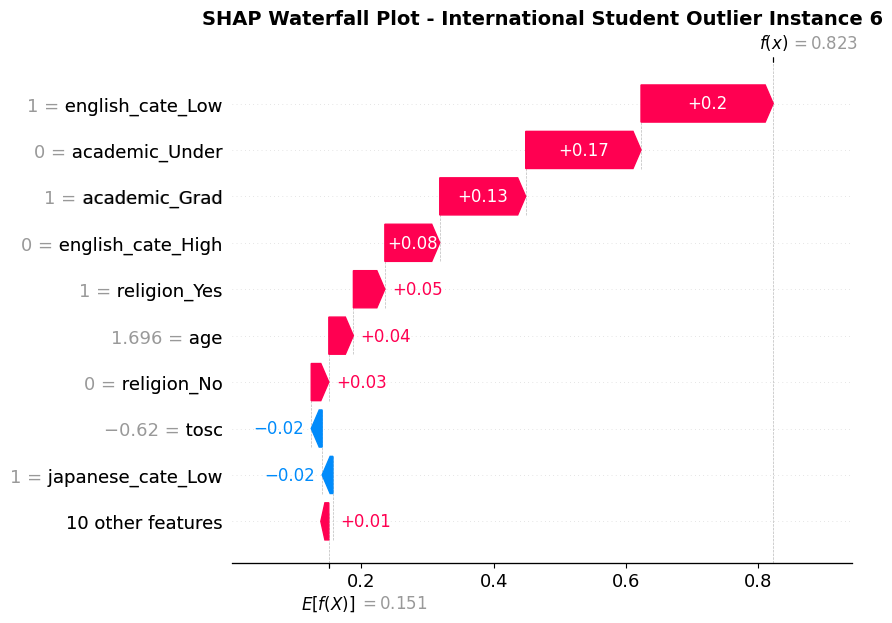

<Figure size 1000x600 with 0 Axes>

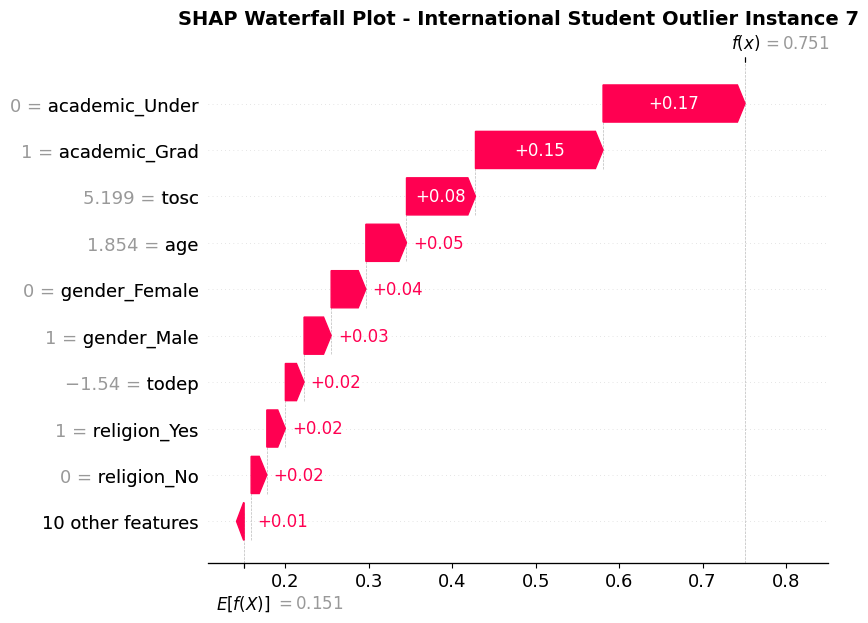

<Figure size 1000x600 with 0 Axes>

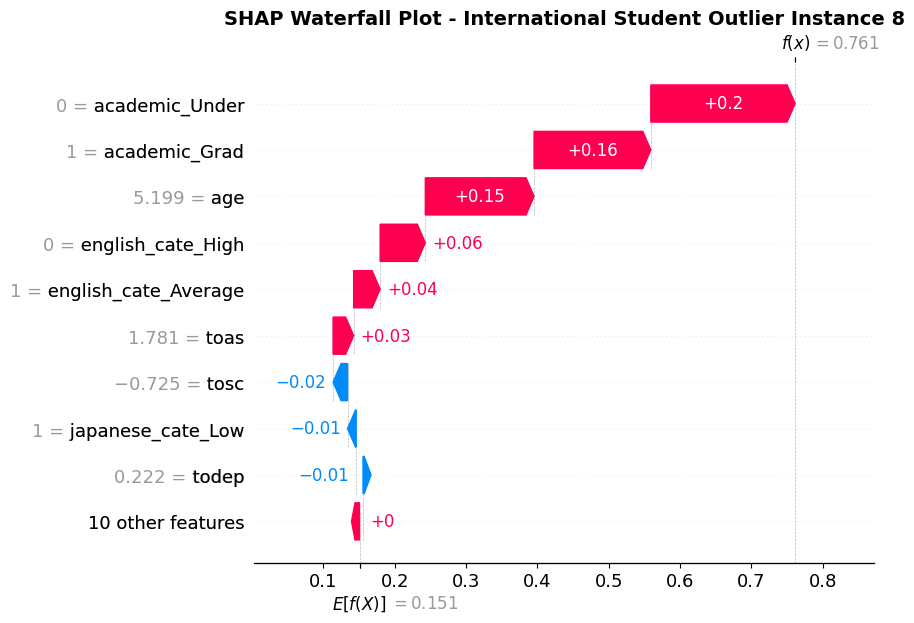

<Figure size 1000x600 with 0 Axes>

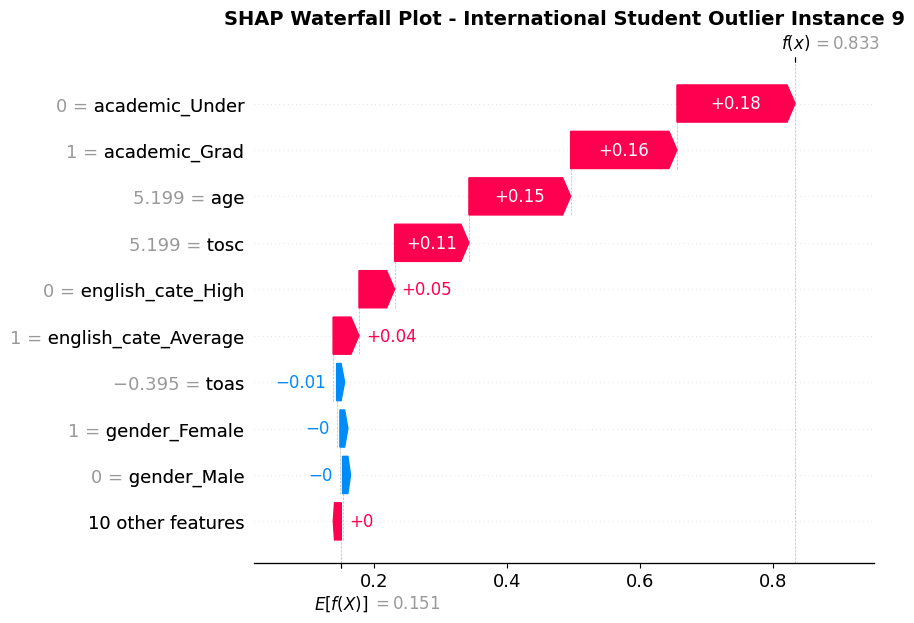

<Figure size 1000x600 with 0 Axes>

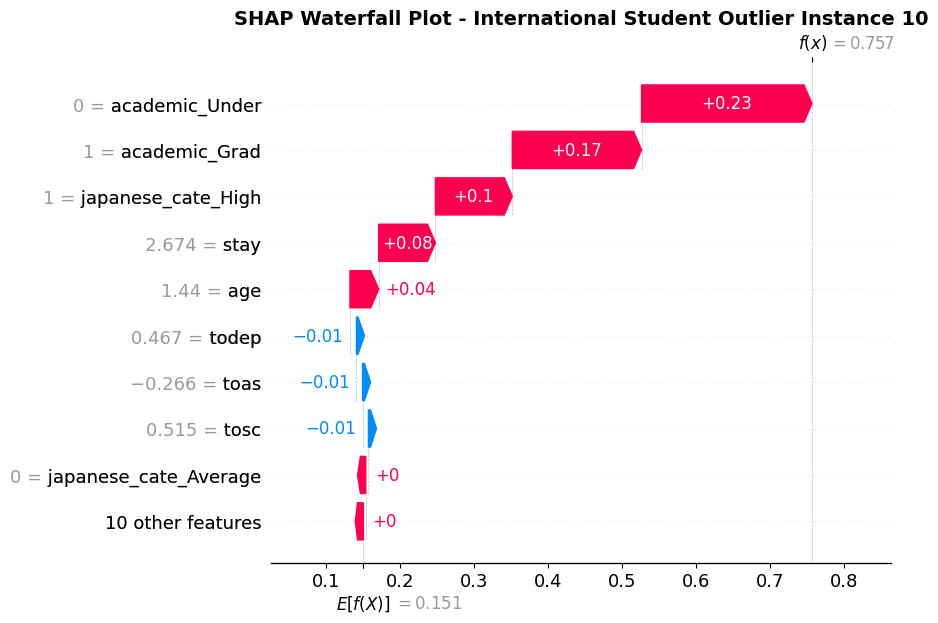

<Figure size 1000x600 with 0 Axes>

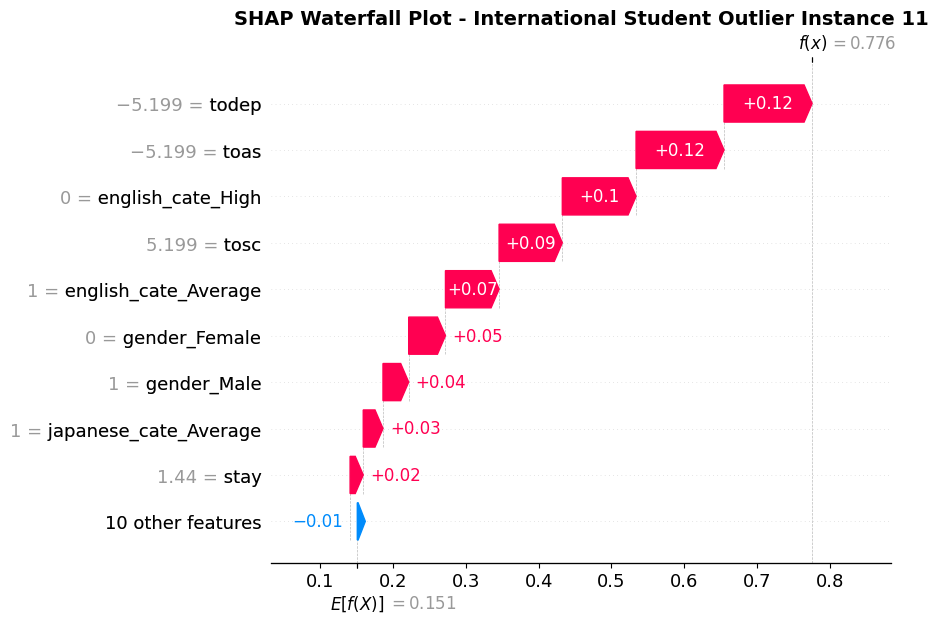

<Figure size 1000x600 with 0 Axes>

In [86]:
iforest = IForest(n_estimators=200, max_samples=0.8, contamination=.3, n_jobs=-1, random_state=10)
iforest.fit(processed_df.values)
probs = iforest.predict_proba(processed_df.values)
iforest_outlier_probs = probs[:, 1]
iforest_outliers = processed_df[iforest_outlier_probs >= 0.75]
num_international_outlier_instances = 11
explainer = shap.KernelExplainer(iforest.predict_proba, shap.kmeans(processed_df, 10))

for i in range(num_international_outlier_instances):
    test_instance = international_outliers.iloc[i, :]
    # Computing ith outlier SHAP value
    shap_values = explainer.shap_values(test_instance)
    # Plotting SHAP waterfall plot of each outlier (IForest)
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Waterfall Plot - International Student Outlier Instance {i+1}", fontsize=14, fontweight='bold')
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[:,1],
            base_values=explainer.expected_value[1],
            data=test_instance,
            feature_names=df.columns
        )
    )
    plt.figure(figsize=(10, 6))
    plt.show()
    plt.close()

#### Investigate two outlier instances with low English proficiency (Outlier 4 and Outlier 6)

100%|██████████| 2/2 [00:00<00:00, 10.94it/s]


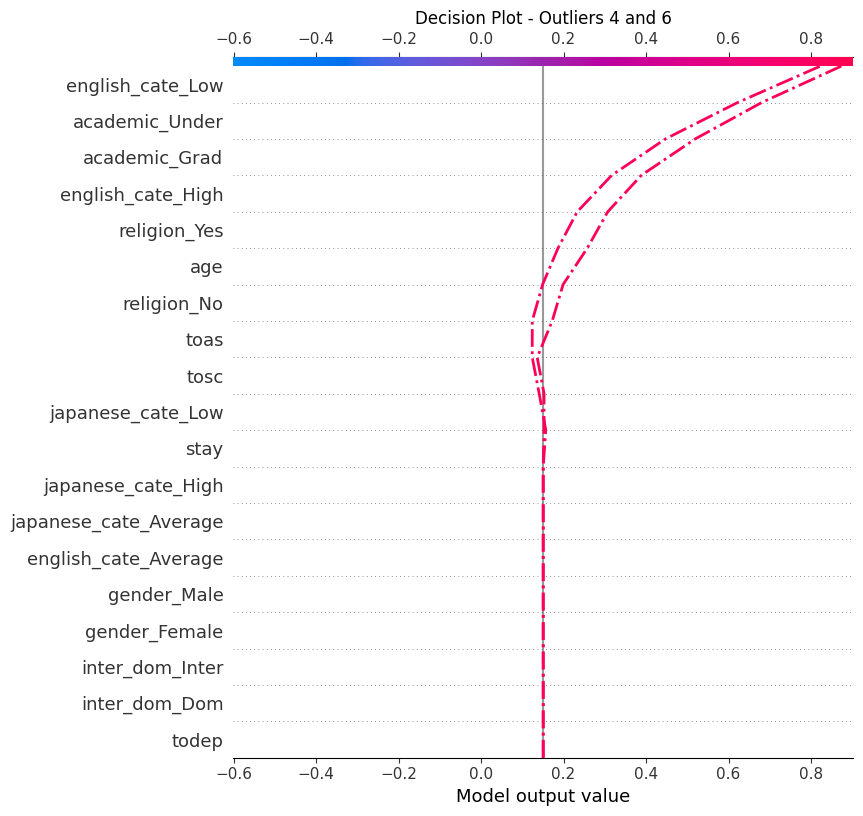

<Figure size 640x480 with 0 Axes>

In [87]:
#plot the decision plot
idx1 = 3
idx2 = 5

instances = international_outliers.iloc[[idx1, idx2]]
shap_values_multi = explainer.shap_values(instances)

shap_values_class1 = shap_values_multi[:, :, 1]

shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    instances,
    feature_names=international_outliers.columns.tolist(),
    highlight=[0, 1],
    title=f"Decision Plot - Outliers {idx1 + 1} and {idx2 + 1}")

plt.tight_layout()
plt.show()

The two outliers follow almost the same decision pattern, with low English proficiency being the driving factor.

#### Investigate two outlier instances with high Japanese proficiency (Outlier 3 and Outlier 10)

100%|██████████| 2/2 [00:00<00:00, 11.44it/s]


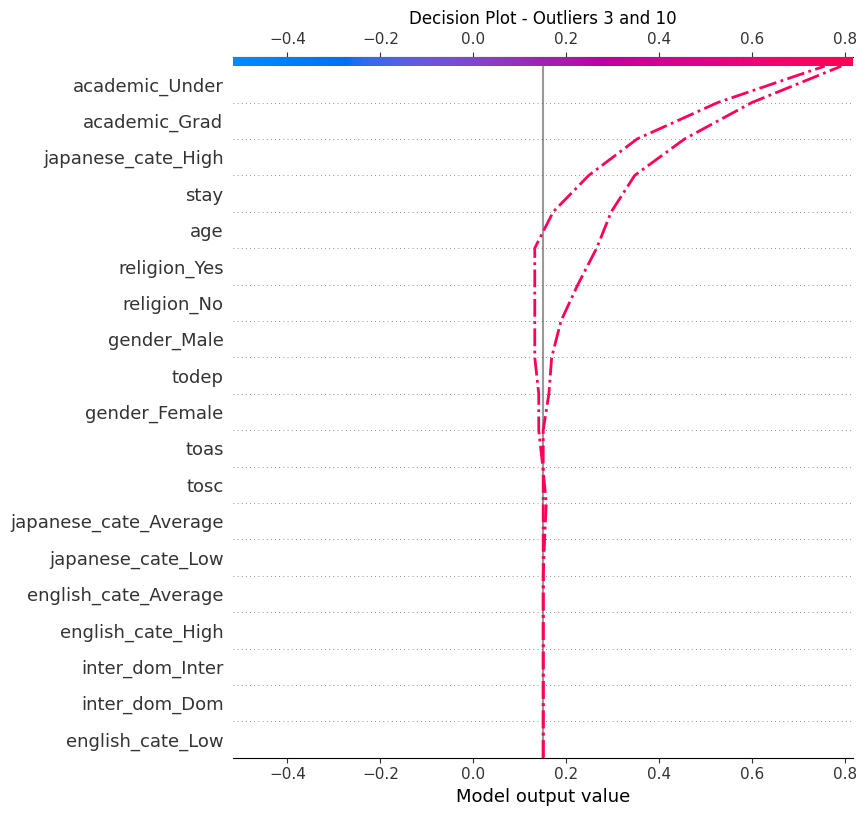

<Figure size 640x480 with 0 Axes>

In [88]:
#plot the decision plot
idx1 = 2
idx2 = 9

instances = international_outliers.iloc[[idx1, idx2]]
shap_values_multi = explainer.shap_values(instances)

shap_values_class1 = shap_values_multi[:, :, 1]

shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    instances,
    feature_names=international_outliers.columns.tolist(),
    highlight=[0, 1],
    title=f"Decision Plot - Outliers {idx1 + 1} and {idx2 + 1}")

plt.tight_layout()
plt.show()

Except for the graduate level that contributes to the output value, which has been discussed earlier, both instances indicate that high Japanese proficiency contributes greatly to anomaly detection.

#### Investigate four outlier instances with older age and higher social connection pressure (Outlier 2, Outlier 5 and Outlier 7)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 10.74it/s]


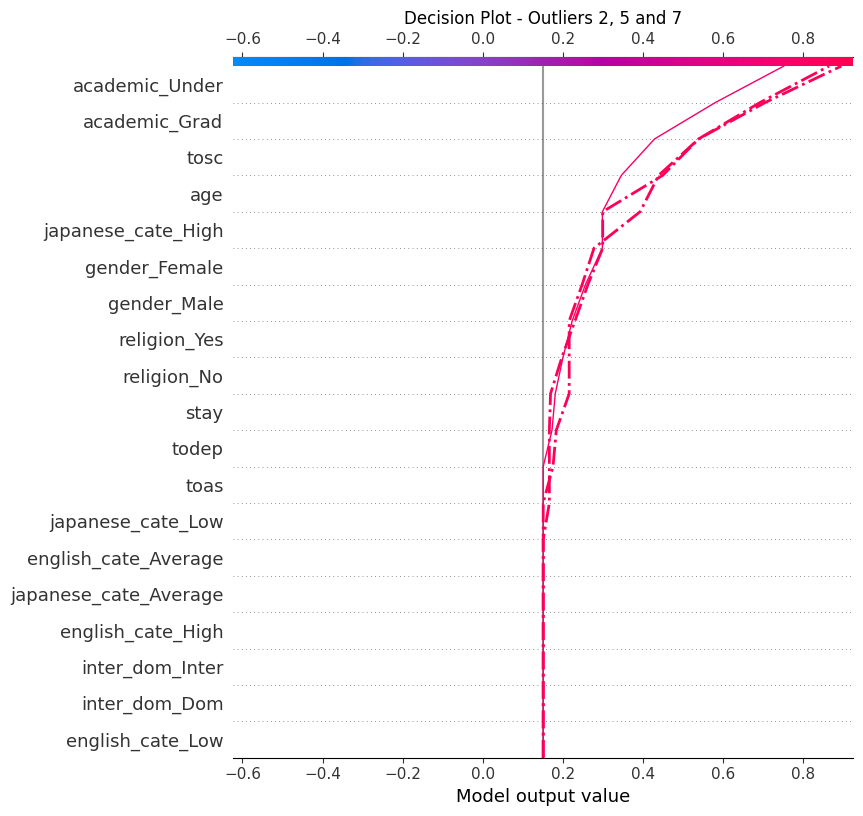

<Figure size 640x480 with 0 Axes>

In [89]:
#plot the decision plot
idx1 = 1
idx2 = 4
idx3 = 6
instances = international_outliers.iloc[[idx1, idx2, idx3]]
shap_values_multi = explainer.shap_values(instances)

shap_values_class1 = shap_values_multi[:, :, 1]

shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    instances,
    feature_names=international_outliers.columns.tolist(),
    highlight=[0, 1],
    title=f"Decision Plot - Outliers {idx1 + 1}, {idx2 + 1} and {idx3 + 1}")

plt.tight_layout()
plt.show()

The four instances share similar pattern, except for the academic level, older age and higher social connection pressure may be the contributing factor.

#### Investigate two outlier instances with extremely low todep (Outlier 1 and Outlier 11)

100%|██████████| 2/2 [00:00<00:00, 10.74it/s]


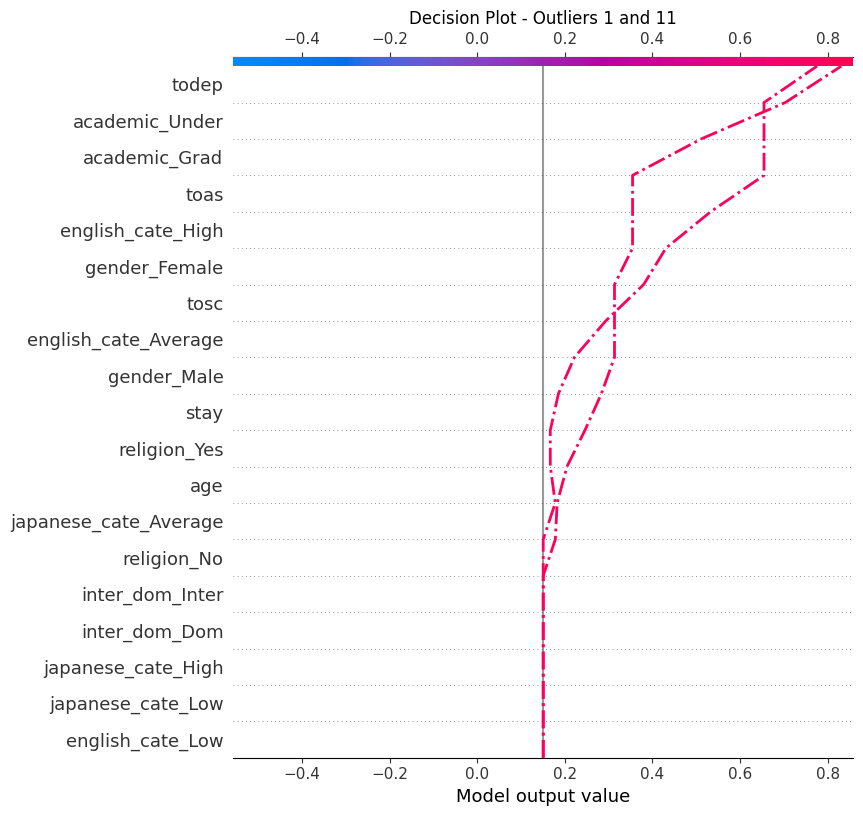

<Figure size 640x480 with 0 Axes>

In [90]:
#plot the decision plot
idx1 = 0
idx2 = 10

instances = international_outliers.iloc[[idx1, idx2]]
shap_values_multi = explainer.shap_values(instances)

shap_values_class1 = shap_values_multi[:, :, 1]

shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    instances,
    feature_names=international_outliers.columns.tolist(),
    highlight=[0, 1],
    title=f"Decision Plot - Outliers {idx1 + 1} and {idx2 + 1}")

plt.tight_layout()
plt.show()

Although both instances are detected as outliers with extremely low todep playing the major role, their differences in academic level, toas and English capability make the decision plot different.

### Plot feature importance plot for international outliers

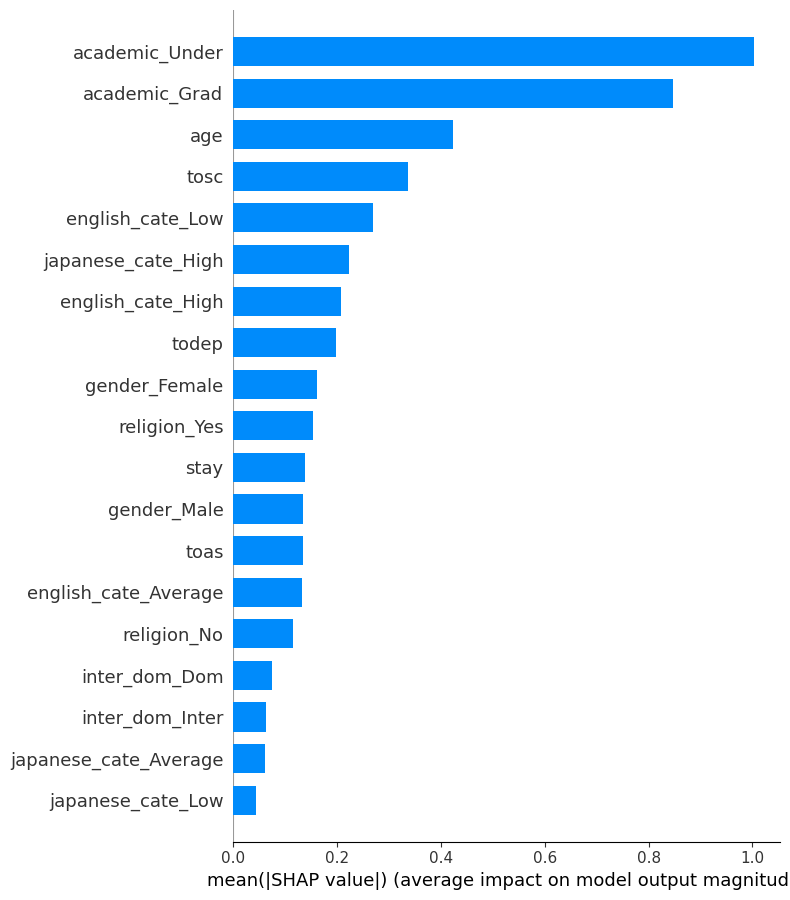

In [91]:
rng = np.random.default_rng(seed=42)
explainer = shap.TreeExplainer(iforest)
shap_values = explainer(international_outliers)
shap.summary_plot(shap_values,international_outliers, plot_type="bar", rng=rng)
